=== 元データ先頭5行 ===
      Date  Price
0  1833-01  18.93
1  1833-02  18.93
2  1833-03  18.93
3  1833-04  18.93
4  1833-05  18.93

=== 元データ列名 ===
['Date', 'Price']

=== 欠損除去後の先頭5行 ===
        Date  Price
0 1833-01-01  18.93
1 1833-02-01  18.93
2 1833-03-01  18.93
3 1833-04-01  18.93
4 1833-05-01  18.93

=== dtypes ===
Date     datetime64[ns]
Price           float64
dtype: object

データ件数: 2311



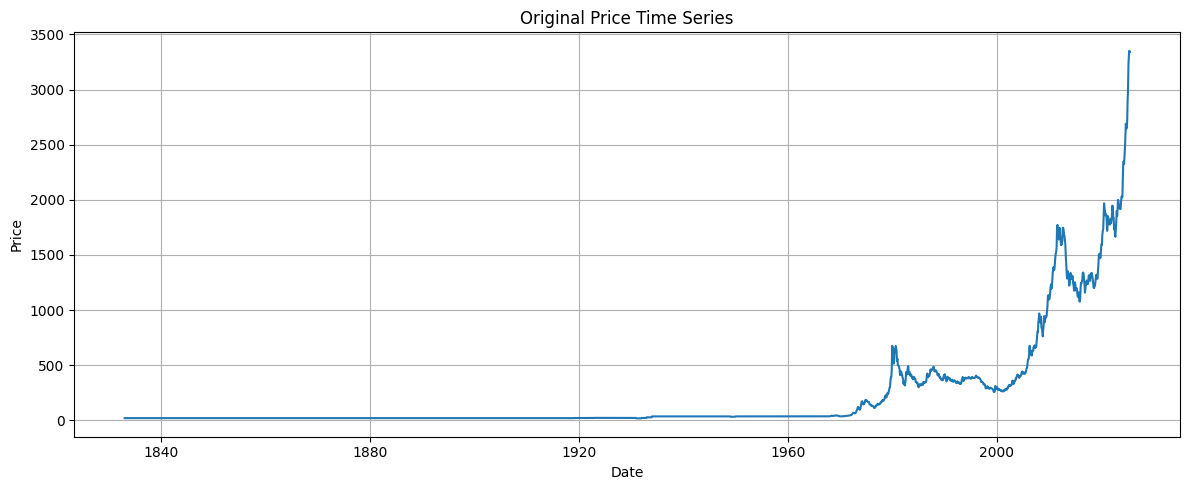

=== ラグ特徴量データ先頭5行 ===
    t-12   t-11   t-10    t-9    t-8    t-7    t-6    t-5    t-4    t-3  \
0  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93   
1  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93   
2  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93   
3  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93   
4  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93  18.93   

     t-2    t-1      t       Date  
0  18.93  18.93  18.93 1834-01-01  
1  18.93  18.93  18.93 1834-02-01  
2  18.93  18.93  18.93 1834-03-01  
3  18.93  18.93  18.93 1834-04-01  
4  18.93  18.93  18.93 1834-05-01  

=== ラグ特徴量 dtypes ===
t-12           float64
t-11           float64
t-10           float64
t-9            float64
t-8            float64
t-7            float64
t-6            float64
t-5            float64
t-4            float64
t-3            float64
t-2            float64
t-1            float64
t             

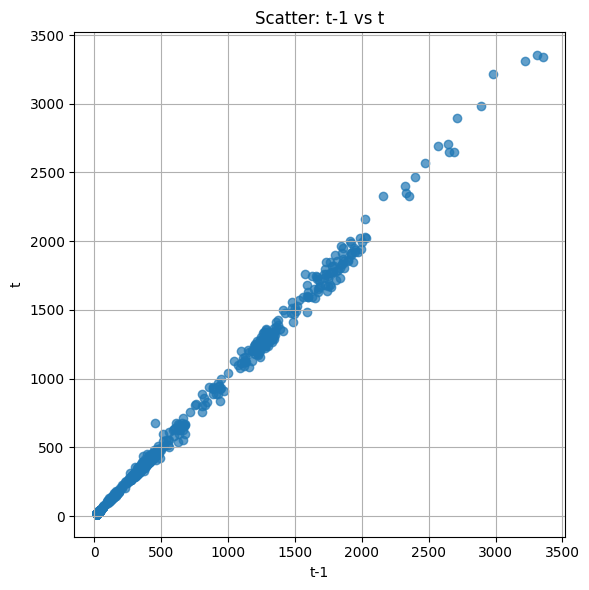

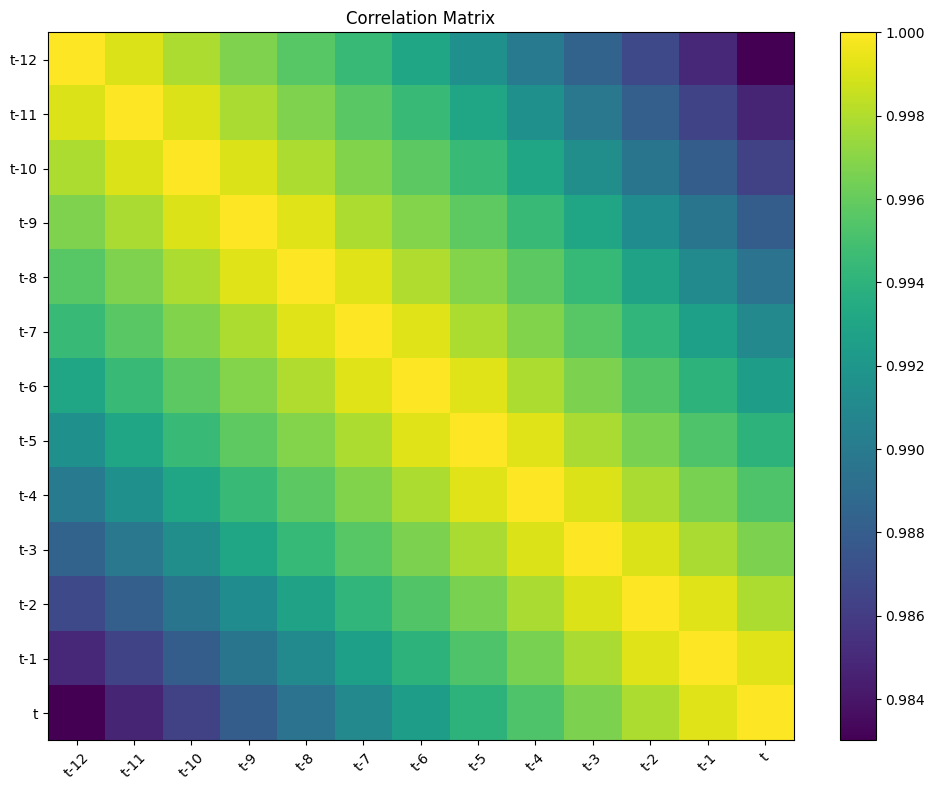

=== 相関行列 ===
          t-12      t-11      t-10       t-9       t-8       t-7       t-6  \
t-12  1.000000  0.999126  0.997887  0.996721  0.995604  0.994441  0.993067   
t-11  0.999126  1.000000  0.999129  0.997874  0.996745  0.995648  0.994488   
t-10  0.997887  0.999129  1.000000  0.999129  0.997901  0.996789  0.995703   
t-9   0.996721  0.997874  0.999129  1.000000  0.999137  0.997923  0.996834   
t-8   0.995604  0.996745  0.997901  0.999137  1.000000  0.999149  0.997952   
t-7   0.994441  0.995648  0.996789  0.997923  0.999149  1.000000  0.999158   
t-6   0.993067  0.994488  0.995703  0.996834  0.997952  0.999158  1.000000   
t-5   0.991564  0.993051  0.994509  0.995751  0.996842  0.997933  0.999141   
t-4   0.990048  0.991522  0.993058  0.994555  0.995746  0.996806  0.997906   
t-3   0.988445  0.989818  0.991380  0.993000  0.994412  0.995560  0.996649   
t-2   0.986730  0.988164  0.989638  0.991298  0.992823  0.994185  0.995365   
t-1   0.984929  0.986464  0.988001  0.989578  0.991

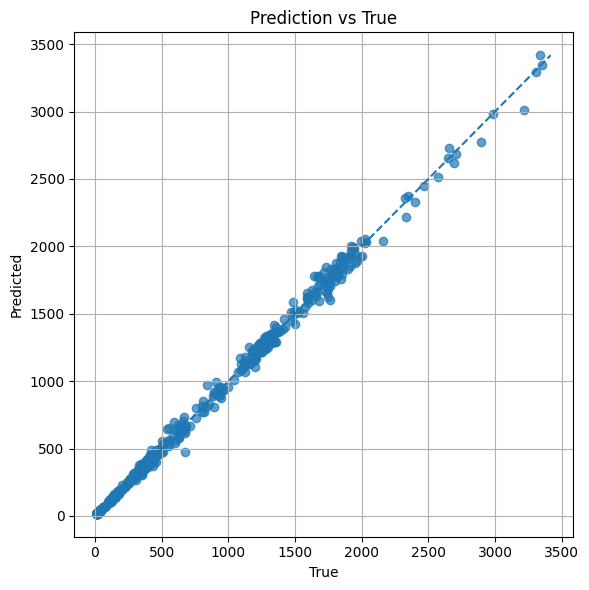

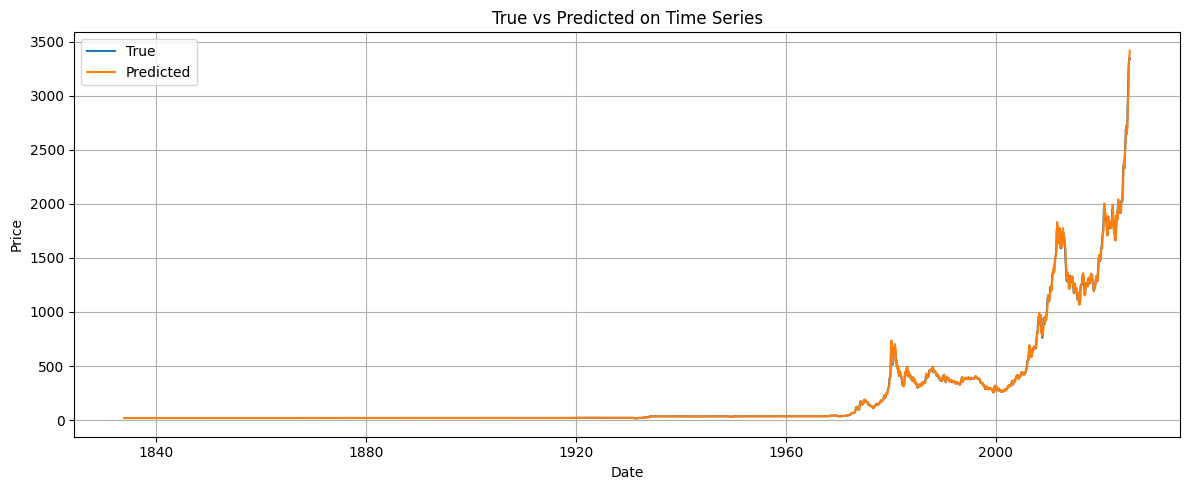

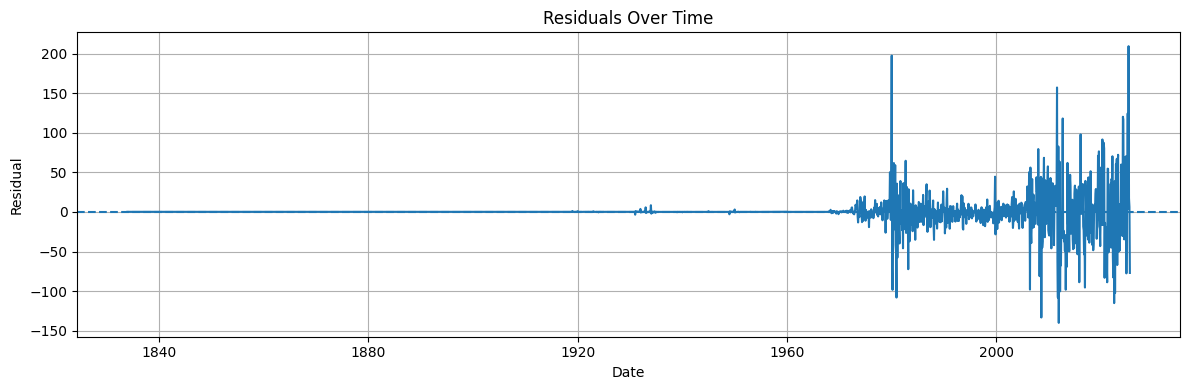

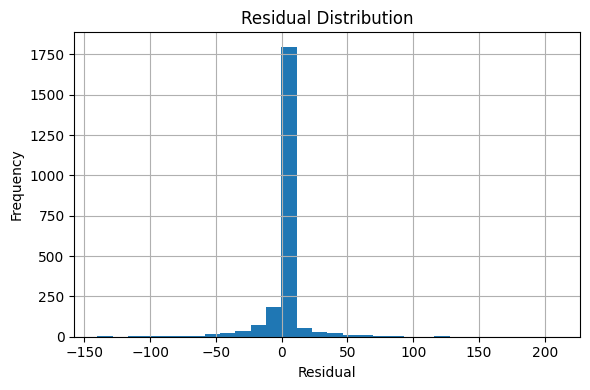

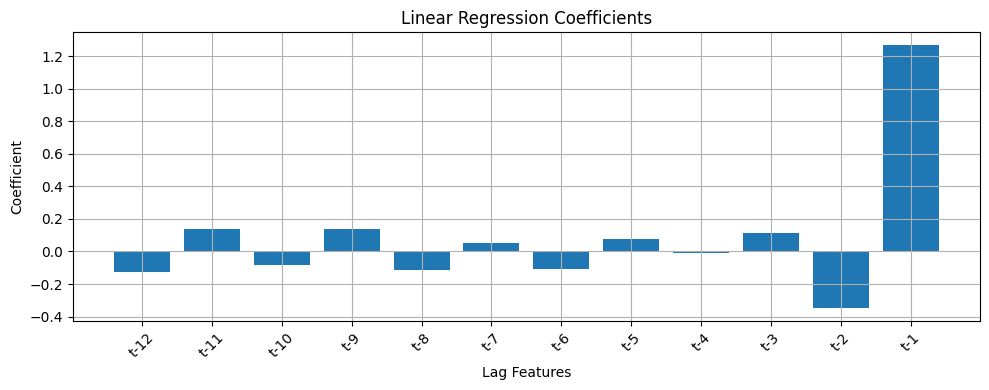

=== SHAP 計算開始 ===


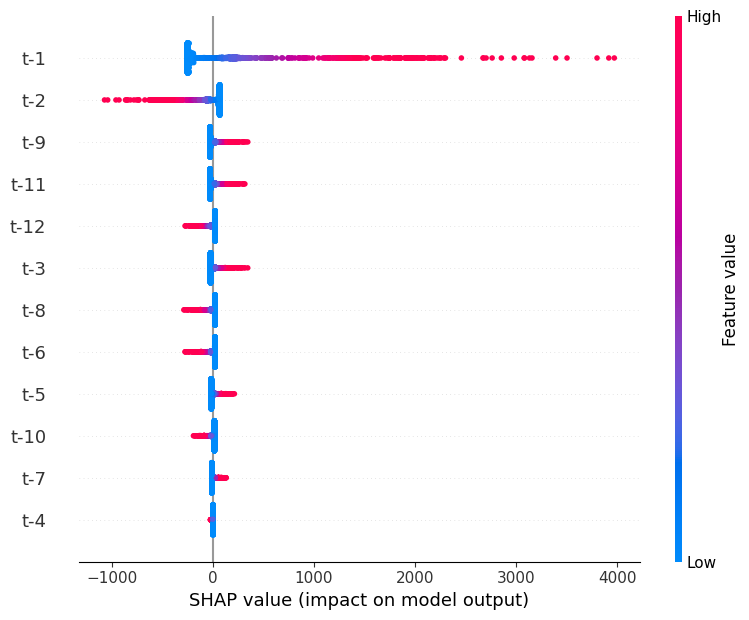

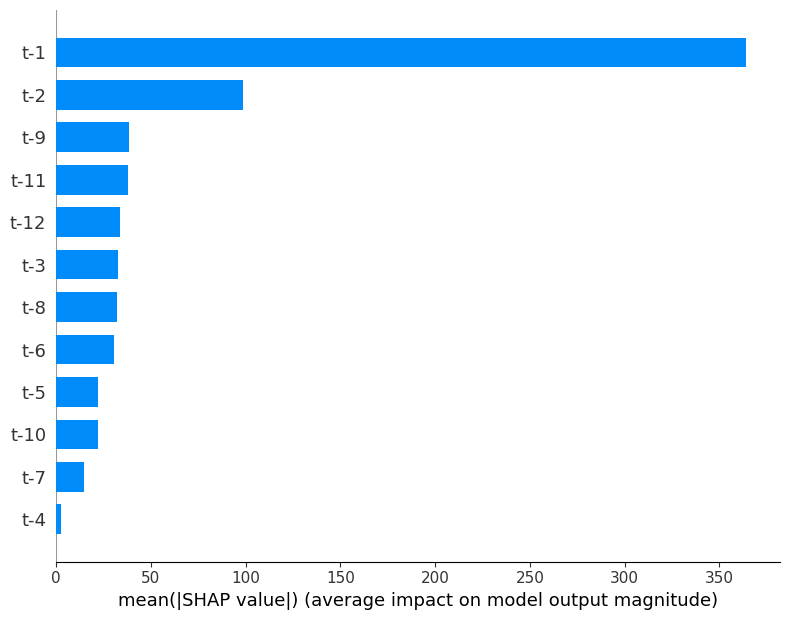

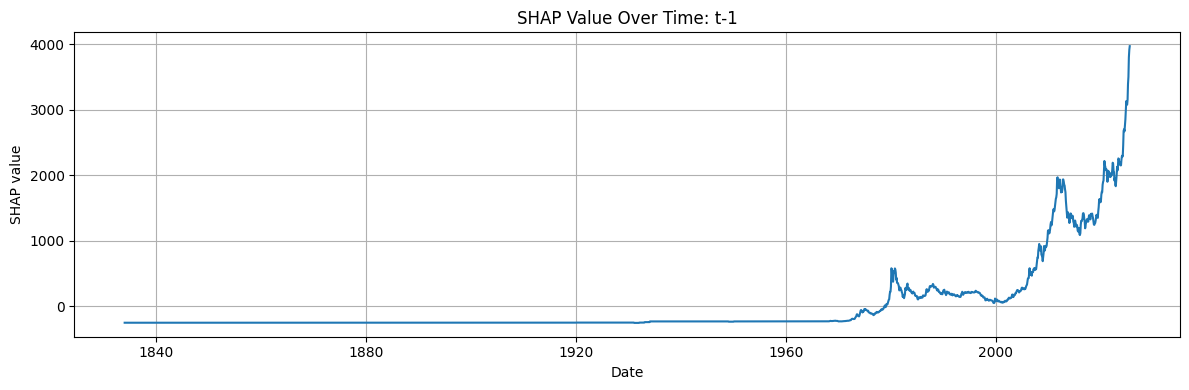

=== LIME 計算開始 ===
LIME explanation index: 60
対象日付: 1839-01-01 00:00:00
実測値: 18.93
予測値: 18.796103374746227

Intercept 416.14783862623864
Prediction_local [-3.37281928]
Right: 18.79610337474623
=== LIME explanation (as_list) ===
[('t-1 <= 18.94', -488.85671023778156), ('t-2 <= 18.94', 124.22796741405698), ('t-11 <= 18.94', -62.5564205578929), ('t-12 <= 18.93', 62.46517047863248), ('t-8 <= 18.94', 53.76402455418515), ('t-7 <= 18.94', -53.086108590068974), ('t-3 <= 18.94', -49.409225150416674), ('t-9 <= 18.94', -47.350200385057086), ('t-10 <= 18.94', 34.43715317487556), ('t-6 <= 18.94', 23.591063904227575), ('t-5 <= 18.94', -8.86335823898182), ('t-4 <= 18.94', -7.884014274372926)]



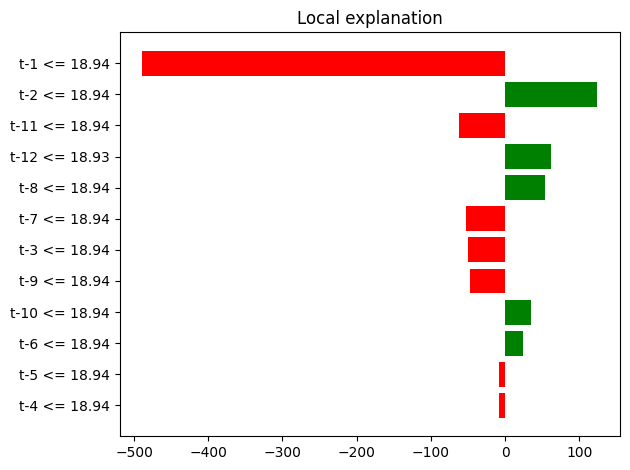

=== 対象サンプルの入力値 ===
t-12    18.93
t-11    18.93
t-10    18.93
t-9     18.93
t-8     18.93
t-7     18.93
t-6     18.93
t-5     18.93
t-4     18.93
t-3     18.93
t-2     18.93
t-1     18.93
Name: 60, dtype: float64

=== 対象サンプルのSHAP値 ===
t-12: 23.3073324961602
t-11: -26.320652936017872
t-10: 15.499948283302512
t-9: -26.71938814876356
t-8: 22.207483270221953
t-7: -10.16220505198189
t-6: 21.132601453894654
t-5: -15.38196120730197
t-4: 1.7444823431146657
t-3: -22.535901171475995
t-2: 67.47537236841926
t-1: -250.020919672422


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================
# 1. CSV読み込み
# =========================================
df = pd.read_csv("monthly.csv")

print("=== 元データ先頭5行 ===")
print(df.head())
print()

print("=== 元データ列名 ===")
print(df.columns.tolist())
print()

# Date, Price を想定
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df = df.dropna(subset=["Date", "Price"]).copy()
df = df.sort_values("Date").reset_index(drop=True)

print("=== 欠損除去後の先頭5行 ===")
print(df.head())
print()

print("=== dtypes ===")
print(df.dtypes)
print()

print("データ件数:", len(df))
print()

# =========================================
# 2. 元データの時系列プロット
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Price"])
plt.title("Original Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================
# 3. 12か月ラグ特徴量の作成
# =========================================
lagged = pd.DataFrame()

for i in range(12, 0, -1):
    lagged[f"t-{i}"] = df["Price"].shift(i)

lagged["t"] = df["Price"]
lagged["Date"] = df["Date"]

lagged = lagged.dropna().reset_index(drop=True)

print("=== ラグ特徴量データ先頭5行 ===")
print(lagged.head())
print()

print("=== ラグ特徴量 dtypes ===")
print(lagged.dtypes)
print()

lagged.to_csv("lags_12months_features_numeric.csv", index=False)
print("保存完了: lags_12months_features_numeric.csv")
print()

# =========================================
# 4. 学習用データ作成
# =========================================
feature_cols = ['t-12', 't-11', 't-10', 't-9', 't-8', 't-7',
                't-6', 't-5', 't-4', 't-3', 't-2', 't-1']
target_col = 't'

X = lagged[feature_cols].copy()
y = lagged[target_col].copy()

# 念のため数値化
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

tmp = pd.concat([X, y], axis=1).dropna()
X = tmp[feature_cols].reset_index(drop=True)
y = tmp[target_col].reset_index(drop=True)

# Date もそろえる
date_for_model = lagged.loc[tmp.index, "Date"].reset_index(drop=True)

print("=== 学習データ shape ===")
print("X:", X.shape)
print("y:", y.shape)
print()

# =========================================
# 5. ラグ構造の簡単な可視化
# =========================================
plt.figure(figsize=(6, 6))
plt.scatter(X["t-1"], y, alpha=0.7)
plt.title("Scatter: t-1 vs t")
plt.xlabel("t-1")
plt.ylabel("t")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================
# 6. 相関行列の可視化
# =========================================
corr_df = pd.concat([X, y.rename("t")], axis=1)
corr = corr_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("=== 相関行列 ===")
print(corr)
print()

# =========================================
# 7. 線形回帰モデル
# =========================================
new_model = LinearRegression()
new_model.fit(X, y)

print("=== 線形回帰 学習完了 ===")
print("coef_:")
for name, coef in zip(feature_cols, new_model.coef_):
    print(f"{name}: {coef}")
print("intercept_:", new_model.intercept_)
print()

# =========================================
# 8. 予測
# =========================================
y_pred = new_model.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("=== 評価指標 ===")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print()

# =========================================
# 9. 予測 vs 実測 散布図
# =========================================
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.7)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Prediction vs True")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================
# 10. 時系列上で実測と予測を比較
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(date_for_model, y, label="True")
plt.plot(date_for_model, y_pred, label="Predicted")
plt.title("True vs Predicted on Time Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================
# 11. 残差プロット
# =========================================
residuals = y - y_pred

plt.figure(figsize=(12, 4))
plt.plot(date_for_model, residuals)
plt.axhline(0, linestyle="--")
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================
# 12. 回帰係数の可視化
# =========================================
plt.figure(figsize=(10, 4))
plt.bar(feature_cols, new_model.coef_)
plt.title("Linear Regression Coefficients")
plt.xlabel("Lag Features")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================
# 13. SHAP
# =========================================
print("=== SHAP 計算開始 ===")
shap_explainer = shap.LinearExplainer(new_model, X)
shap_values = shap_explainer(X)

# summary plot
shap.summary_plot(shap_values, X)

# bar plot
shap.summary_plot(shap_values, X, plot_type="bar")

# =========================================
# 14. SHAP値を時系列で見る（例: t-1）
# =========================================
shap_values_array = shap_values.values

if "t-1" in X.columns:
    idx_t1 = list(X.columns).index("t-1")

    plt.figure(figsize=(12, 4))
    plt.plot(date_for_model, shap_values_array[:, idx_t1])
    plt.title("SHAP Value Over Time: t-1")
    plt.xlabel("Date")
    plt.ylabel("SHAP value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================================
# 15. LIME
# =========================================
print("=== LIME 計算開始 ===")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X),
    mode='regression',
    feature_names=X.columns.tolist(),
    class_names=['t'],
    verbose=True
)

# 説明したいサンプル番号
i = 60
if i >= len(X):
    i = len(X) - 1

print(f"LIME explanation index: {i}")
print("対象日付:", date_for_model.iloc[i])
print("実測値:", y.iloc[i])
print("予測値:", y_pred[i])
print()

exp = lime_explainer.explain_instance(
    data_row=np.array(X.iloc[i]),
    predict_fn=new_model.predict,
    num_features=12
)

print("=== LIME explanation (as_list) ===")
print(exp.as_list())
print()

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# =========================================
# 16. 追加: 任意サンプルの特徴量確認
# =========================================
print("=== 対象サンプルの入力値 ===")
print(X.iloc[i])
print()

print("=== 対象サンプルのSHAP値 ===")
for col, val in zip(X.columns, shap_values_array[i]):
    print(f"{col}: {val}")